Loading model and feature objects...
  Best model   : XGBoost
  Test samples : 6,519
  Features     : 19

F1: Computing SHAP values...
  SHAP values computed: shape = (6519, 19)
  Expected (base) value: 0.0070

F2: Generating global SHAP beeswarm plot...


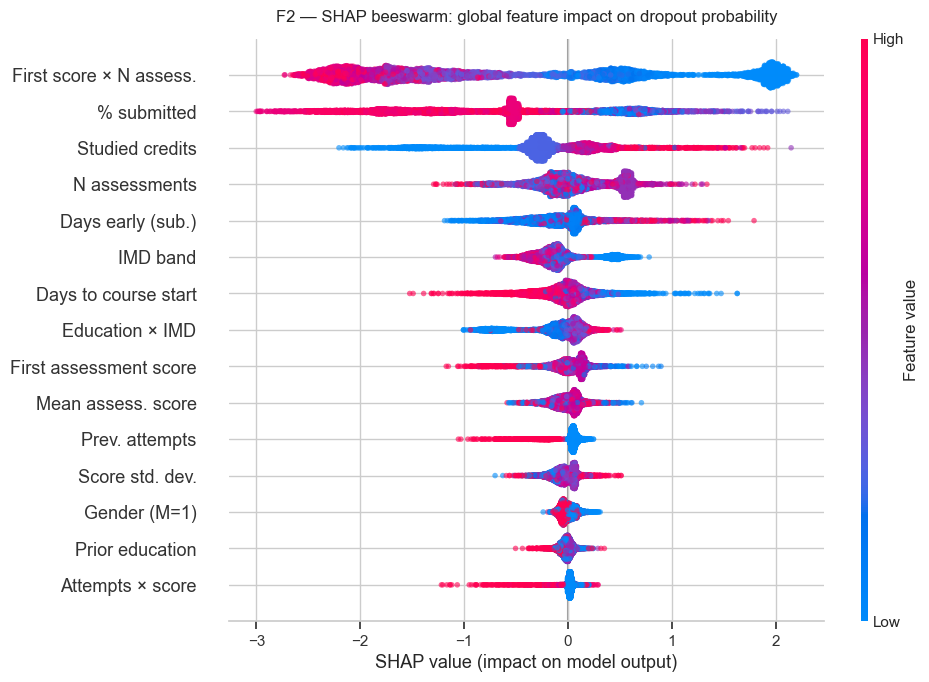

  Saved → ./outputs/phase4/block_f/F2_shap_beeswarm.png

F3: Plotting mean |SHAP| importance bar chart...


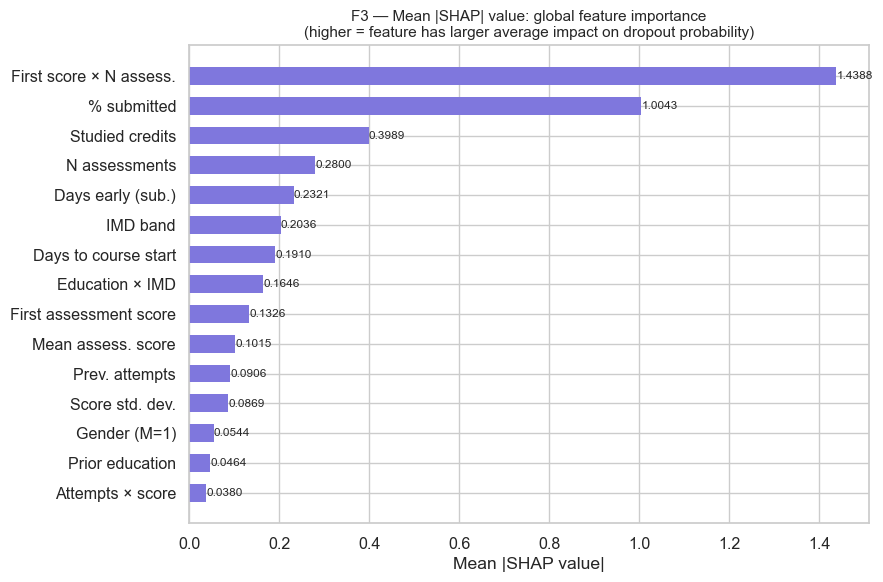

  Saved → ./outputs/phase4/block_f/F3_shap_importance_bar.png

  Top 10 features by mean |SHAP|:
    First score × N assess.             1.4388
    % submitted                         1.0043
    Studied credits                     0.3989
    N assessments                       0.2800
    Days early (sub.)                   0.2321
    IMD band                            0.2036
    Days to course start                0.1910
    Education × IMD                     0.1646
    First assessment score              0.1326
    Mean assess. score                  0.1015

F4: Plotting SHAP dependence plot for top feature...


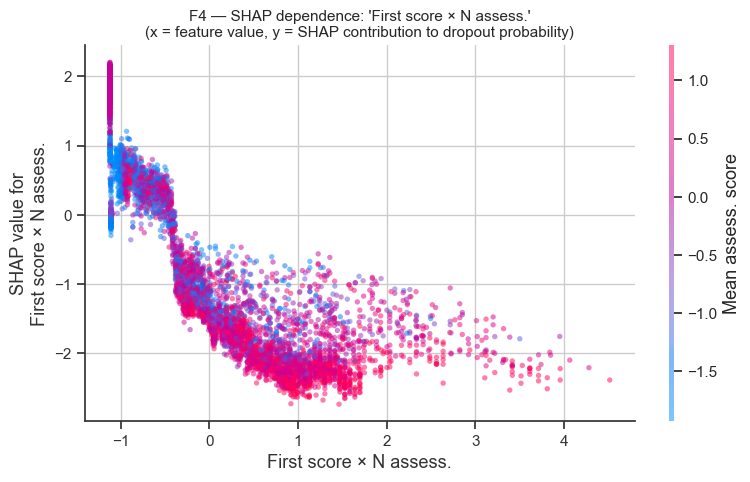

  Saved → ./outputs/phase4/block_f/F4_shap_dependence.png

F5: Generating local waterfall plot for highest-risk student...
  Highest-risk student index: 5325
  Predicted dropout probability: 0.9931
  Actual outcome: WITHDREW (dropout)



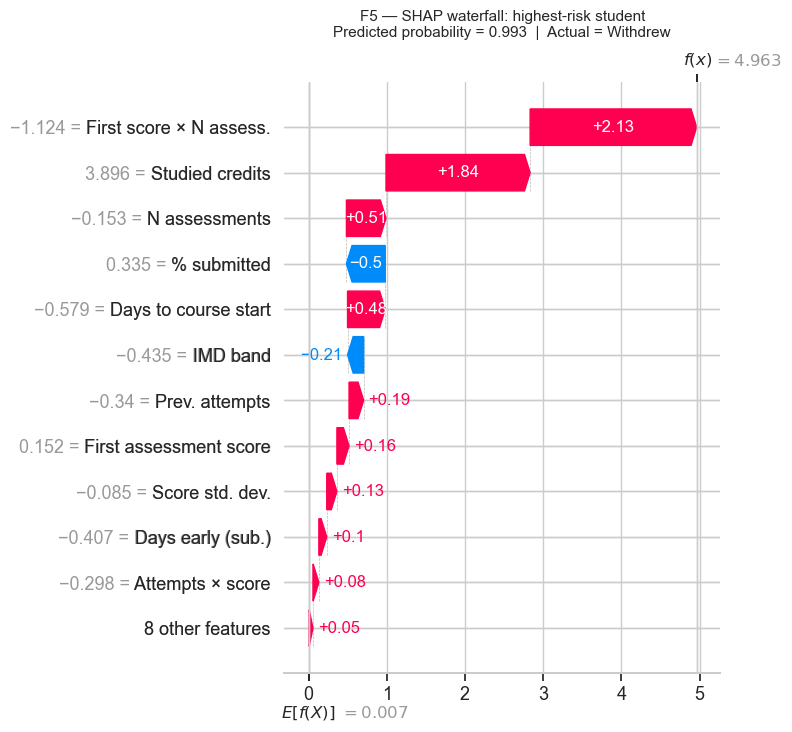

  Saved → ./outputs/phase4/block_f/F5_shap_waterfall_high_risk.png

F6: Generating waterfall plot for lowest-risk student...
  Lowest-risk student index: 2569
  Predicted dropout probability: 0.0009
  Actual outcome: Did not withdraw



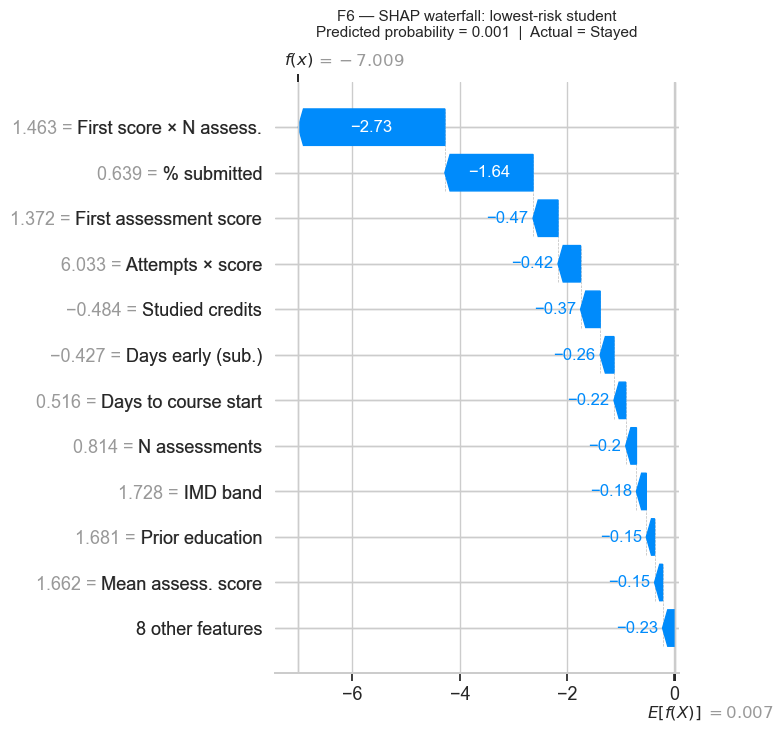

  Saved → ./outputs/phase4/block_f/F6_shap_waterfall_low_risk.png

F7: Generating SHAP interaction heatmap (sample of 200 students)...


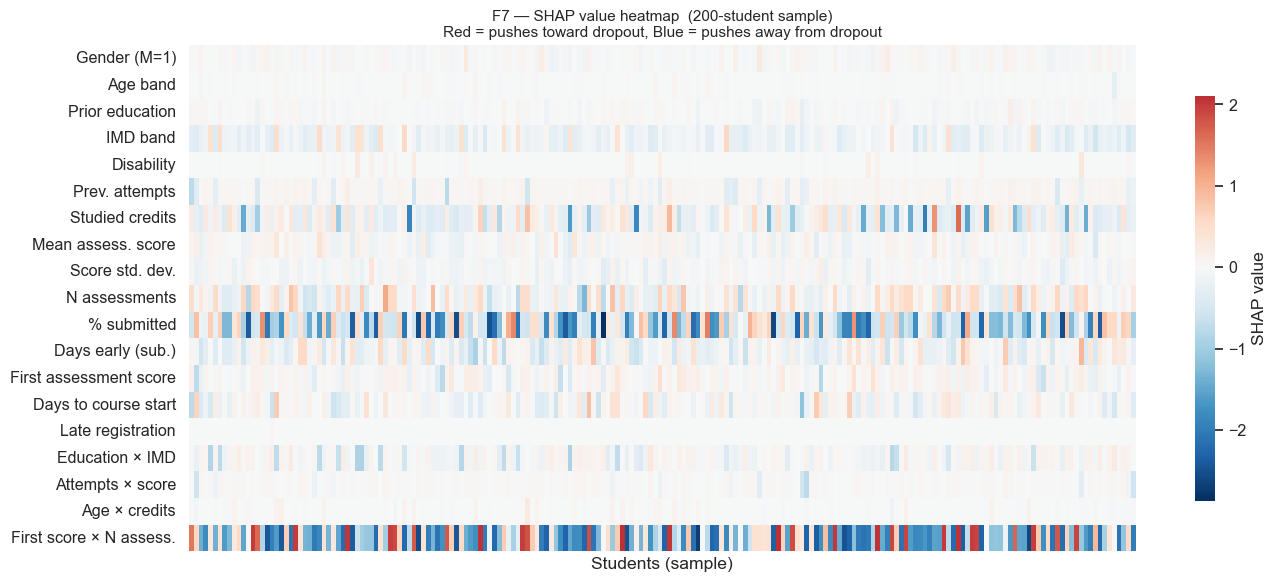

  Saved → ./outputs/phase4/block_f/F7_shap_heatmap.png

BLOCK F COMPLETE — SHAP Explainability

  Model explained  : XGBoost
  SHAP explainer   : TreeExplainer
  Students explained: 6,519

  Top 5 features by mean |SHAP|:

    First score × N assess.             1.4388
    % submitted                         1.0043
    Studied credits                     0.3989
    N assessments                       0.2800
    Days early (sub.)                   0.2321

  Local explanations:
    Highest-risk student (p=0.993): F5_shap_waterfall_high_risk.png
    Lowest-risk student  (p=0.001): F6_shap_waterfall_low_risk.png

  Charts saved to: ./outputs/phase4/block_f/
    F2_shap_beeswarm.png
    F3_shap_importance_bar.png
    F4_shap_dependence.png
    F5_shap_waterfall_high_risk.png
    F6_shap_waterfall_low_risk.png
    F7_shap_heatmap.png

PHASE 4 IS COMPLETE — ALL BLOCKS DONE
  Block A — Feature engineering        ✅
  Block B — SMOTE class imbalance      ✅
  Block C — Model training             

In [1]:
"""
=============================================================
Phase 4 — Block F: SHAP Explainability
=============================================================
Goal: Explain WHY the model flags specific students as at-risk
      using SHAP (SHapley Additive exPlanations).

What is SHAP?
  SHAP assigns each feature a contribution value for each
  individual prediction. It answers:
    "How much did feature X push this student's dropout
     probability up or down compared to the average?"

  It is based on Shapley values from cooperative game theory:
  each feature is treated as a "player" and its contribution
  is the average marginal contribution across all possible
  feature orderings.

  SHAP values have a key property: they SUM to the difference
  between the model's prediction for this student and the
  average prediction across all students. This makes them
  fully additive and interpretable.

Two levels of explanation:
  Global (F1–F3): What matters most overall?
    • Summary beeswarm plot — shows direction and magnitude
    • Bar chart of mean |SHAP| per feature
    • Dependence plot for the top feature

  Local (F4–F5): Why was THIS student flagged?
    • Waterfall plot for the highest-risk student
    • Force plot showing push/pull of each feature

Why SHAP matters for the portfolio:
  Showing explainability separates a toy model from a real
  decision-support tool. Advisors need to understand WHY
  a student is flagged before acting — SHAP provides that.
"""

import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

# Config
BLOCK_A_PATH = './outputs/phase4/block_a/'
BLOCK_D_PATH = './outputs/phase4/block_d/'
OUTPUT_PATH  = './outputs/phase4/block_f/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

COLORS = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'coral':  '#D85A30',
    'gray':   '#888780',
    'purple': '#7F77DD',
    'amber':  '#BA7517',
}
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)


# =============================================================
# LOAD OBJECTS
# =============================================================
print("Loading model and feature objects...")

with open(os.path.join(BLOCK_A_PATH, 'block_a_objects.pkl'), 'rb') as f:
    a_obj = pickle.load(f)

with open(os.path.join(BLOCK_D_PATH, 'block_d_objects.pkl'), 'rb') as f:
    d_obj = pickle.load(f)

best_model      = d_obj['best_model']
best_model_name = d_obj['best_model_name']
X_test_scaled   = d_obj['X_test']
X_test_raw      = a_obj['X_test_raw']
y_test          = a_obj['y_test']
FEATURES        = a_obj['feature_names']

# Friendly display names for features
FEATURE_LABELS = {
    'gender_enc':          'Gender (M=1)',
    'age_enc':             'Age band',
    'edu_enc':             'Prior education',
    'imd_enc':             'IMD band',
    'disab_enc':           'Disability',
    'num_of_prev_attempts':'Prev. attempts',
    'studied_credits':     'Studied credits',
    'mean_score':          'Mean assess. score',
    'std_score':           'Score std. dev.',
    'n_assessments':       'N assessments',
    'pct_submitted':       '% submitted',
    'mean_days_early':     'Days early (sub.)',
    'first_score':         'First assessment score',
    'days_to_start':       'Days to course start',
    'late_registration':   'Late registration',
    'edu_x_imd':           'Education × IMD',
    'attempts_x_score':    'Attempts × score',
    'age_x_credits':       'Age × credits',
    'first_score_x_n':     'First score × N assess.',
}
display_names = [FEATURE_LABELS.get(f, f) for f in FEATURES]

print(f"  Best model   : {best_model_name}")
print(f"  Test samples : {X_test_scaled.shape[0]:,}")
print(f"  Features     : {len(FEATURES)}\n")


# =============================================================
# F1: Compute SHAP values
# =============================================================
# SHAP has different explainers for different model types:
#   TreeExplainer   → Random Forest, XGBoost, Decision Tree (fast, exact)
#   LinearExplainer → Logistic Regression (fast, exact)
#   KernelExplainer → any model (slow, approximate — fallback)
#
# We auto-select the right explainer based on the best model type.

print("F1: Computing SHAP values...")

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

if isinstance(best_model, (RandomForestClassifier, DecisionTreeClassifier, XGBClassifier)):
    # TreeExplainer is exact and fast for tree-based models
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_scaled)

    # For binary classification, tree models return a list [class0, class1]
    # We want SHAP values for class 1 (dropout)
    if isinstance(shap_values, list):
        sv = shap_values[1]
    else:
        sv = shap_values

    expected_value = (
        explainer.expected_value[1]
        if isinstance(explainer.expected_value, (list, np.ndarray))
        else explainer.expected_value
    )

elif isinstance(best_model, LogisticRegression):
    # LinearExplainer for logistic regression
    explainer   = shap.LinearExplainer(best_model, X_test_scaled)
    shap_values_obj = explainer(X_test_scaled)
    sv              = shap_values_obj.values
    expected_value  = explainer.expected_value

else:
    # KernelExplainer as fallback — slower, uses a sample background
    background   = shap.sample(X_test_scaled, 100, random_state=42)
    explainer    = shap.KernelExplainer(best_model.predict_proba, background)
    shap_values  = explainer.shap_values(X_test_scaled[:200])
    sv           = shap_values[1]
    expected_value = explainer.expected_value[1]

print(f"  SHAP values computed: shape = {sv.shape}")
print(f"  Expected (base) value: {expected_value:.4f}\n")

# Build a tidy SHAP Explanation object for modern SHAP plots
explanation = shap.Explanation(
    values      = sv,
    base_values = np.full(len(sv), expected_value),
    data        = X_test_scaled,
    feature_names = display_names,
)


# =============================================================
# F2: Global — SHAP beeswarm summary plot
# =============================================================
# Shows every test-set student as a dot.
# x-axis = SHAP value (positive = pushes toward dropout)
# Colour  = feature value (red = high, blue = low)
# Features sorted by mean |SHAP| (most important at top)
#
# How to read it:
#   A wide spread means the feature has a large range of effects.
#   Red dots on the right = high feature value → higher dropout risk.
#   Blue dots on the right = low feature value → higher dropout risk.

print("F2: Generating global SHAP beeswarm plot...")

fig, ax = plt.subplots(figsize=(10, 7))
plt.sca(ax)

shap.summary_plot(
    sv,
    X_test_scaled,
    feature_names=display_names,
    plot_type='dot',       # beeswarm
    show=False,
    max_display=15,        # top 15 features
    plot_size=None,
    alpha=0.6,
)

ax.set_title("F2 — SHAP beeswarm: global feature impact on dropout probability",
             fontsize=12, pad=12)
plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "F2_shap_beeswarm.png")
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# F3: Global — Mean |SHAP| bar chart
# =============================================================
# The mean absolute SHAP value per feature is the cleanest
# measure of global feature importance in SHAP.
# Unlike tree-based feature importance (which counts splits),
# SHAP importance reflects the actual impact on predictions.

print("F3: Plotting mean |SHAP| importance bar chart...")

mean_abs_shap = np.abs(sv).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=display_names).sort_values(ascending=True)

# Keep top 15 for readability
shap_importance = shap_importance.tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(shap_importance.index, shap_importance.values,
               color=COLORS['purple'], edgecolor='none', height=0.6)

for bar, val in zip(bars, shap_importance.values):
    ax.text(val + 0.0005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va='center', fontsize=8.5)

ax.set_title("F3 — Mean |SHAP| value: global feature importance\n"
             "(higher = feature has larger average impact on dropout probability)",
             fontsize=11)
ax.set_xlabel("Mean |SHAP value|")
plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "F3_shap_importance_bar.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")

# Print the ranking
print("  Top 10 features by mean |SHAP|:")
for feat, val in shap_importance.sort_values(ascending=False).head(10).items():
    print(f"    {feat:<35} {val:.4f}")
print()


# =============================================================
# F4: Global — SHAP dependence plot for the top feature
# =============================================================
# A dependence plot shows how the SHAP value for the top feature
# varies across its range of values.
# Colour = most-interacting secondary feature (auto-selected by SHAP).
# This reveals non-linear effects and interactions.

print("F4: Plotting SHAP dependence plot for top feature...")

top_feature_display = shap_importance.idxmax()
top_feature_idx     = display_names.index(top_feature_display)

fig, ax = plt.subplots(figsize=(8, 5))
plt.sca(ax)

shap.dependence_plot(
    top_feature_idx,
    sv,
    X_test_scaled,
    feature_names=display_names,
    show=False,
    ax=ax,
    dot_size=15,
    alpha=0.5,
)

ax.set_title(
    f"F4 — SHAP dependence: '{top_feature_display}'\n"
    f"(x = feature value, y = SHAP contribution to dropout probability)",
    fontsize=11
)
plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "F4_shap_dependence.png")
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# F5: Local — Waterfall plot for the highest-risk student
# =============================================================
# The waterfall plot shows one student's prediction broken down
# feature by feature. It starts at the model's average prediction
# (base value) and shows how each feature pushed it up or down
# to arrive at this student's final dropout probability.
#
# This is the most compelling chart for portfolio presentations:
# it translates a black-box score into a human-readable story.
# "This student's dropout risk is high primarily because of
# their low assessment score and high previous attempts."

print("F5: Generating local waterfall plot for highest-risk student...")

# Find the student with the highest predicted dropout probability
proba_test = best_model.predict_proba(X_test_scaled)[:, 1]
highest_risk_idx = np.argmax(proba_test)
highest_risk_prob = proba_test[highest_risk_idx]

print(f"  Highest-risk student index: {highest_risk_idx}")
print(f"  Predicted dropout probability: {highest_risk_prob:.4f}")
print(f"  Actual outcome: {'WITHDREW (dropout)' if y_test[highest_risk_idx]==1 else 'Did not withdraw'}")
print()

# Waterfall uses the Explanation object (row = single student)
single_explanation = explanation[highest_risk_idx]

fig, ax = plt.subplots(figsize=(10, 7))
plt.sca(ax)

shap.waterfall_plot(single_explanation, show=False, max_display=12)

plt.title(
    f"F5 — SHAP waterfall: highest-risk student\n"
    f"Predicted probability = {highest_risk_prob:.3f}  |  "
    f"Actual = {'Withdrew' if y_test[highest_risk_idx]==1 else 'Stayed'}",
    fontsize=11, pad=10
)
plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "F5_shap_waterfall_high_risk.png")
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# F6: Local — Waterfall for a correctly-predicted LOW-risk student
# =============================================================
# For contrast, show the SHAP explanation for the student the
# model is most confident WON'T drop out.
# This helps demonstrate that SHAP works symmetrically.

print("F6: Generating waterfall plot for lowest-risk student...")

lowest_risk_idx  = np.argmin(proba_test)
lowest_risk_prob = proba_test[lowest_risk_idx]

print(f"  Lowest-risk student index: {lowest_risk_idx}")
print(f"  Predicted dropout probability: {lowest_risk_prob:.4f}")
print(f"  Actual outcome: {'WITHDREW' if y_test[lowest_risk_idx]==1 else 'Did not withdraw'}")
print()

single_low = explanation[lowest_risk_idx]

fig, ax = plt.subplots(figsize=(10, 7))
plt.sca(ax)

shap.waterfall_plot(single_low, show=False, max_display=12)

plt.title(
    f"F6 — SHAP waterfall: lowest-risk student\n"
    f"Predicted probability = {lowest_risk_prob:.3f}  |  "
    f"Actual = {'Withdrew' if y_test[lowest_risk_idx]==1 else 'Stayed'}",
    fontsize=11, pad=10
)
plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "F6_shap_waterfall_low_risk.png")
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# F7: SHAP interaction heatmap
# =============================================================
# Shows the mean absolute SHAP value for every student as a
# heatmap (students × features). Reveals which features drive
# predictions for different subgroups of students.

print("F7: Generating SHAP interaction heatmap (sample of 200 students)...")

sample_idx = np.random.choice(len(sv), size=min(200, len(sv)), replace=False)
sv_sample  = sv[sample_idx]

fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    sv_sample.T,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    cbar_kws={'label': 'SHAP value', 'shrink': 0.8},
    xticklabels=False,
    yticklabels=display_names,
    linewidths=0,
)
ax.set_title(
    "F7 — SHAP value heatmap  (200-student sample)\n"
    "Red = pushes toward dropout, Blue = pushes away from dropout",
    fontsize=11
)
ax.set_xlabel("Students (sample)")
ax.set_ylabel("")
plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "F7_shap_heatmap.png")
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# BLOCK F SUMMARY
# =============================================================
print("=" * 60)
print("BLOCK F COMPLETE — SHAP Explainability")
print("=" * 60)
print(f"""
  Model explained  : {best_model_name}
  SHAP explainer   : {'TreeExplainer' if isinstance(best_model, (RandomForestClassifier, DecisionTreeClassifier, XGBClassifier)) else 'LinearExplainer'}
  Students explained: {sv.shape[0]:,}

  Top 5 features by mean |SHAP|:
""")
for feat, val in shap_importance.sort_values(ascending=False).head(5).items():
    print(f"    {feat:<35} {val:.4f}")

print(f"""
  Local explanations:
    Highest-risk student (p={highest_risk_prob:.3f}): F5_shap_waterfall_high_risk.png
    Lowest-risk student  (p={lowest_risk_prob:.3f}): F6_shap_waterfall_low_risk.png

  Charts saved to: {OUTPUT_PATH}
    F2_shap_beeswarm.png
    F3_shap_importance_bar.png
    F4_shap_dependence.png
    F5_shap_waterfall_high_risk.png
    F6_shap_waterfall_low_risk.png
    F7_shap_heatmap.png

{'='*60}
PHASE 4 IS COMPLETE — ALL BLOCKS DONE
{'='*60}
  Block A — Feature engineering        ✅
  Block B — SMOTE class imbalance      ✅
  Block C — Model training             ✅
  Block D — Model comparison           ✅
  Block E — Dropout risk scoring       ✅
  Block F — SHAP explainability        ✅

─────────────────────────────────────────────────────────
Next → Phase 5: Insights Report
  Compile all findings into a final portfolio report,
  executive summary, and presentation-ready visuals.
─────────────────────────────────────────────────────────
""")